In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
airbnb = pd.read_csv("dataset/listings.csv")
airbnb

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
0,1.318800e+04,Riley Park,Entire home/apt,4,1.0,0.0,2.0,14
1,1.335800e+04,Downtown,Entire home/apt,2,1.0,1.0,1.0,20
2,1.349000e+04,Kensington-Cedar Cottage,Entire home/apt,2,1.0,1.0,1.0,35
3,1.426700e+04,Kensington-Cedar Cottage,Entire home/apt,4,1.0,1.0,2.0,35
4,1.625400e+04,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,3.0,36
...,...,...,...,...,...,...,...,...
4981,9.970000e+17,Downtown,Entire home/apt,4,1.0,1.0,2.0,3000
4982,9.970000e+17,South Cambie,Entire home/apt,4,NaN,2.0,NaN,5714
4983,9.970000e+17,South Cambie,Private room,2,1.0,1.0,0.0,8495
4984,9.970000e+17,Downtown,Entire home/apt,4,NaN,2.0,NaN,9600


In [4]:
airbnb["price"].mean()

np.float64(249.16526273565984)

In [ ]:
np.random.seed(100) 
airbnb.sample(n=40)["price"].mean()

np.float64(200.3)

In [19]:
sample_list = []

for i in range(20_000):
    sample = airbnb.sample(n=40) 
    sample = sample.assign(replicate = i)
    sample_list.append(sample)

In [20]:
samples = pd.concat(sample_list)
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
3681,7.760000e+17,Kerrisdale,Entire home/apt,8,2.0,3.0,3.0,280,0
4274,8.930000e+17,Downtown,Entire home/apt,4,2.0,2.0,2.0,376,0
2505,5.112903e+07,Downtown,Entire home/apt,3,1.0,1.0,2.0,189,0
2688,5.328129e+07,Kitsilano,Entire home/apt,4,1.0,2.0,2.0,200,0
4379,9.080000e+17,Kerrisdale,Private room,1,0.5,1.0,1.0,400,0
...,...,...,...,...,...,...,...,...,...
4605,9.360000e+17,Dunbar Southlands,Entire home/apt,3,1.0,2.0,0.0,498,19999
2216,4.619898e+07,West End,Entire home/apt,4,1.0,1.0,2.0,172,19999
1190,2.680136e+07,Hastings-Sunrise,Private room,2,NaN,NaN,NaN,125,19999
2101,4.349773e+07,West End,Entire home/apt,4,NaN,2.0,NaN,165,19999


In [23]:
sample_estimates = samples.groupby("replicate")["price"].mean().reset_index(name="sample_mean")

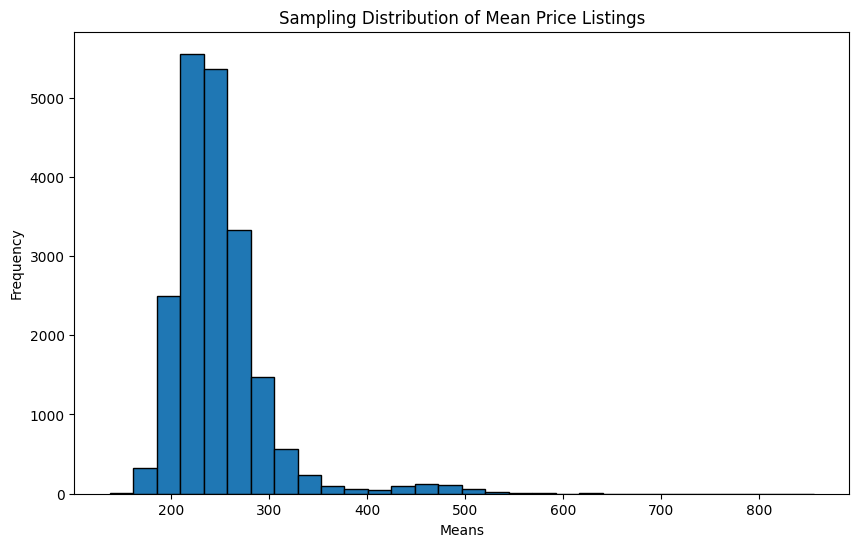

In [24]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [25]:
###### BOOTSTRAPPING

np.random.seed(1234)
one_sample = airbnb.sample(n=40)
one_sample["price"].mean()

np.float64(219.85)

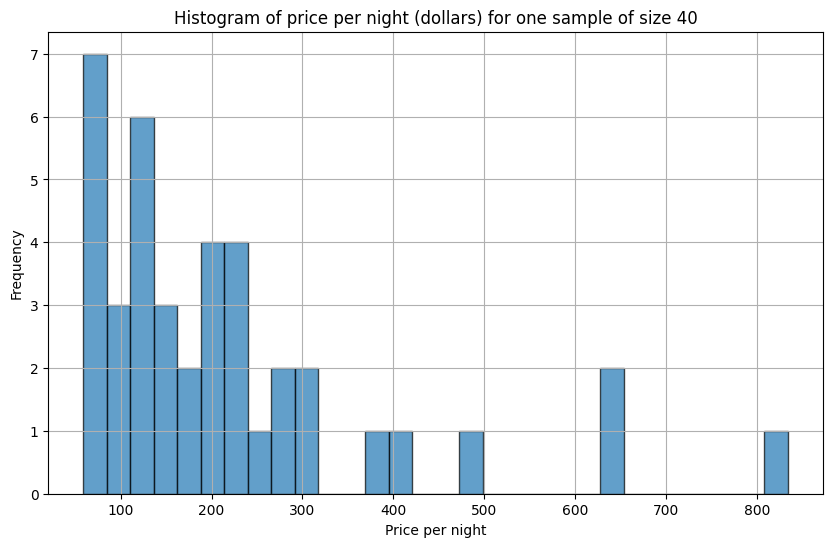

In [26]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [27]:
boot1 = one_sample.sample(frac=1, replace=True)

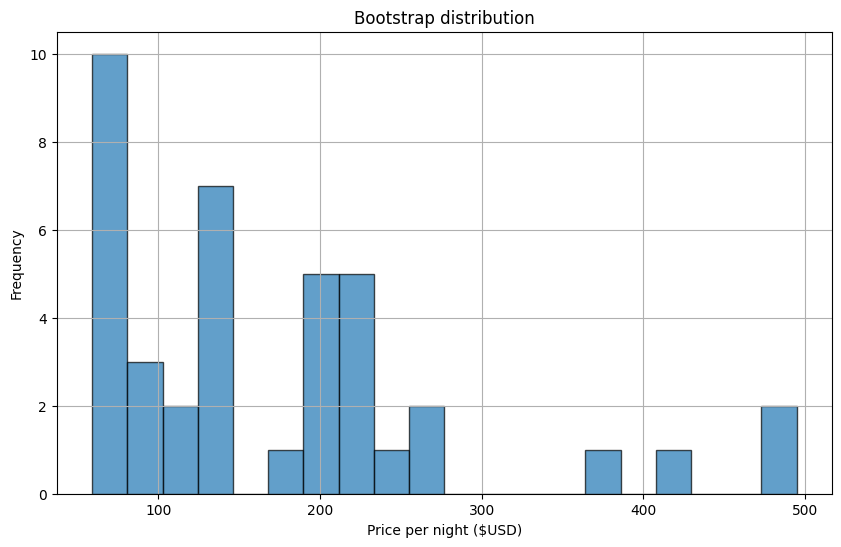

In [28]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [29]:
bootstrap_samples = []

for i in range(20_000):
    sample = one_sample.sample(frac = 1, replace=True)
    sample = sample.assign(replicate = i)
    bootstrap_samples.append(sample)

In [30]:
boot2000 = pd.concat(bootstrap_samples)

In [33]:
boot_means = boot2000.groupby("replicate")["price"].mean().reset_index(name="mean_price")

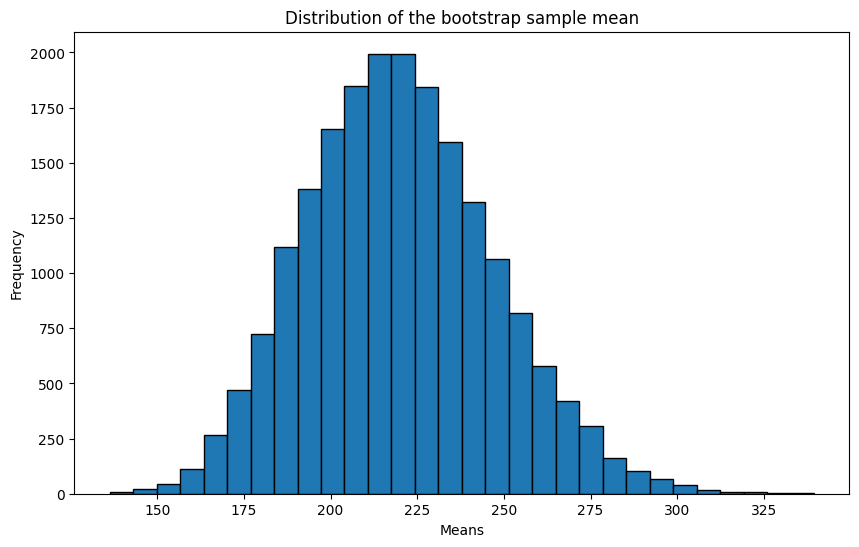

In [34]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Distribution of the bootstrap sample mean')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [35]:
boot_means["mean_price"].quantile([0.025,0.975])

0.025    171.248750
0.975    276.300625
Name: mean_price, dtype: float64